
📊 Model Evaluation for FP_D_Count using SVR (5-min resolution):
Mean Absolute Error (MAE): 0.06
Root Mean Squared Error (RMSE): 0.08
R² Score: 0.97


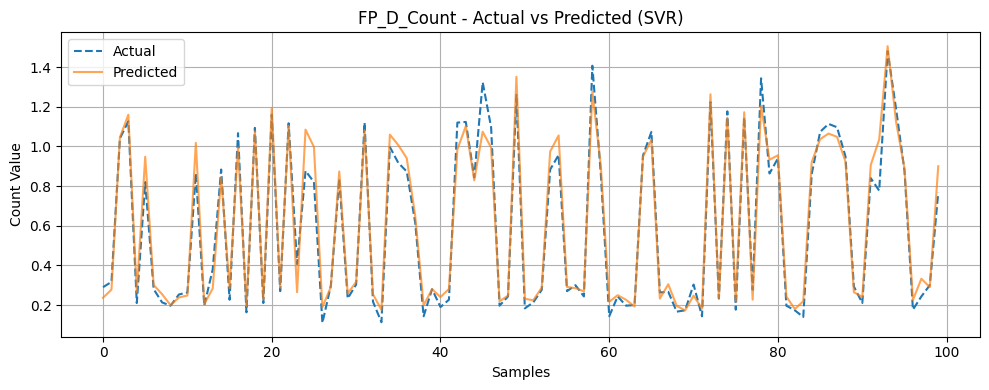

In [ ]:
#SVM, lag=2


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity

# Load the data
file_path = "junction_data_race_course.csv"
df = pd.read_csv(file_path)

# ---------------- STEP 1: DOWNSAMPLE TO 5 MINUTES ----------------
df_downsampled = df.groupby(np.arange(len(df)) // 300).mean(numeric_only=True).reset_index(drop=True)

# ---------------- STEP 2: CREATE LAG FEATURES + COSINE ----------------
def create_lagged_features_with_cosine(data, target_col="FP_D_Count", lag=2):
    if target_col not in data.columns:
        raise ValueError(f"{target_col} not found in dataset.")

    relevant_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    lagged = data[relevant_cols].copy()

    for l in range(1, lag + 1):
        for col in relevant_cols:
            lagged[f"{col}_lag{l}"] = data[col].shift(l)

    lagged = lagged.dropna().reset_index(drop=True)

    lag_cols = [col for col in lagged.columns if '_lag' in col]
    lagged_features = lagged[lag_cols]
    cos_sim_matrix = cosine_similarity(lagged_features)
    lagged['cosine_similarity'] = np.diag(cos_sim_matrix)

    feature_cols = [col for col in lagged.columns if col != target_col]
    X = lagged[feature_cols]
    y = lagged[target_col]
    return X, y

# ---------------- STEP 3: SVM REGRESSION ----------------
def run_svm_with_advanced_features(data, lag=2, target_col="FP_D_Count"):
    X, y = create_lagged_features_with_cosine(data, target_col=target_col, lag=lag)

    # Standardize features (very important for SVM)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    # Train SVR model
    model = SVR(kernel='rbf', C=100, epsilon=0.1)
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n📊 Model Evaluation for FP_D_Count using SVR (5-min resolution):")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")

    # Plot actual vs predicted
    plt.figure(figsize=(10, 4))
    plt.plot(np.array(y_test[:100]), label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title(f"{target_col} - Actual vs Predicted (SVR)")
    plt.xlabel("Samples")
    plt.ylabel("Count Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ---------------- RUN FINAL SVM CODE ----------------
lag_value = 2
run_svm_with_advanced_features(df_downsampled, lag=lag_value)


Fitting 3 folds for each of 36 candidates, totalling 108 fits
🔍 Best Parameters Found: {'C': 1, 'epsilon': 0.01, 'gamma': 0.01}

📊 Tuned SVM Model Evaluation:
MAE: 0.04
RMSE: 0.06
R²: 0.98


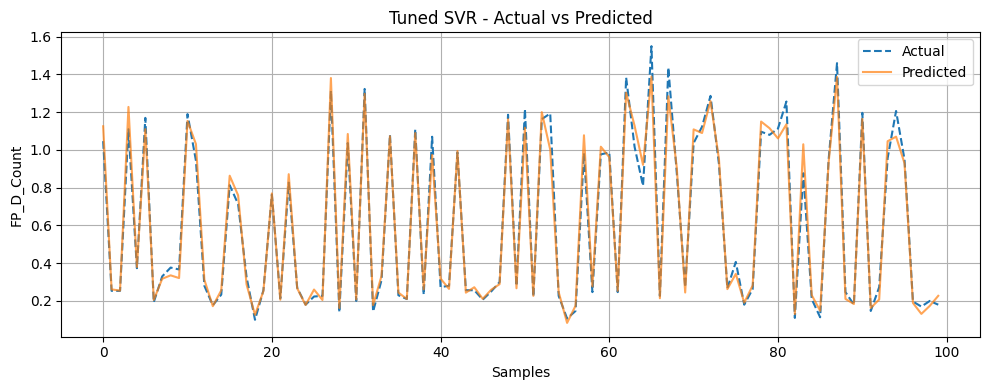

In [ ]:
#Using GridSearch

import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("junction_data_race_course.csv")

# ---------------- STEP 1: DOWNSAMPLE TO 5 MINUTES ----------------
df_downsampled = df.groupby(np.arange(len(df)) // 300).mean(numeric_only=True).reset_index(drop=True)

# ---------------- STEP 2: CREATE LAG FEATURES + COSINE ----------------
def create_lagged_features_with_cosine(data, target_col="FP_D_Count", lag=2):
    relevant_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    lagged = data[relevant_cols].copy()

    for l in range(1, lag + 1):
        for col in relevant_cols:
            lagged[f"{col}_lag{l}"] = data[col].shift(l)

    lagged = lagged.dropna().reset_index(drop=True)
    lag_cols = [col for col in lagged.columns if '_lag' in col]
    lagged_features = lagged[lag_cols]

    cos_sim_matrix = cosine_similarity(lagged_features)
    lagged['cosine_similarity'] = np.diag(cos_sim_matrix)

    feature_cols = [col for col in lagged.columns if col != target_col]
    X = lagged[feature_cols]
    y = lagged[target_col]
    return X, y

# ---------------- STEP 3: TUNED SVR WITH GRIDSEARCH ----------------
def run_tuned_svr(data, target_col="FP_D_Count", lag=2):
    X, y = create_lagged_features_with_cosine(data, target_col, lag)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    # Grid Search parameters
    param_grid = {
        'C': [1, 10, 100],
        'epsilon': [0.01, 0.1, 0.5],
        'gamma': ['scale', 0.01, 0.1, 1]
    }

    svr = SVR(kernel='rbf')
    grid_search = GridSearchCV(svr, param_grid, cv=3, scoring='neg_mean_squared_error', verbose=1)
    grid_search.fit(X_train, y_train)

    print("🔍 Best Parameters Found:", grid_search.best_params_)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n📊 Tuned SVM Model Evaluation:")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.2f}")

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(np.array(y_test[:100]), label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title("Tuned SVR - Actual vs Predicted")
    plt.xlabel("Samples")
    plt.ylabel("FP_D_Count")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ---------------- RUN IT ----------------
run_tuned_svr(df_downsampled, target_col="FP_D_Count", lag=2)


<ipython-input-2-6012421b60b8>:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lagged[f"{col}_lag{l}"] = data[col].shift(l)
<ipython-input-2-6012421b60b8>:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lagged[f"{col}_lag{l}"] = data[col].shift(l)
<ipython-input-2-6012421b60b8>:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, 


📊 Model Evaluation for FP_D_Count using SVR (5-min resolution, lag=5):
Mean Absolute Error (MAE): 0.06
Root Mean Squared Error (RMSE): 0.08
R² Score: 0.97

🧪 Features in X_test (first 5 rows):
       Time  FP_A_Count  FP_A_QueuePct  FP_A_Speed  FP_B_Count  FP_B_QueuePct  \
0 -0.853073    1.579128       1.157651    0.855123    0.301528       0.352240   
1  1.201290    2.058576       1.743238    0.768103    0.475170       0.525109   
2 -0.178326    0.989039       0.534048    1.373247    0.874547       0.987840   
3  0.365086   -1.160572      -1.227168   -1.080801   -1.070247      -1.120642   
4 -0.602452   -1.023587      -0.887772   -1.068179   -1.052882      -1.049049   

   FP_B_Speed  FP_C_Count  FP_C_QueuePct  FP_C_Speed  ...  \
0    0.414416    0.709713       0.788653    1.187885  ...   
1    1.240332    1.394497       1.440901    1.395850  ...   
2    0.853028    0.761394       0.690248    0.836194  ...   
3   -1.167041   -1.086230      -1.015439   -1.106907  ...   
4   -1.095468 

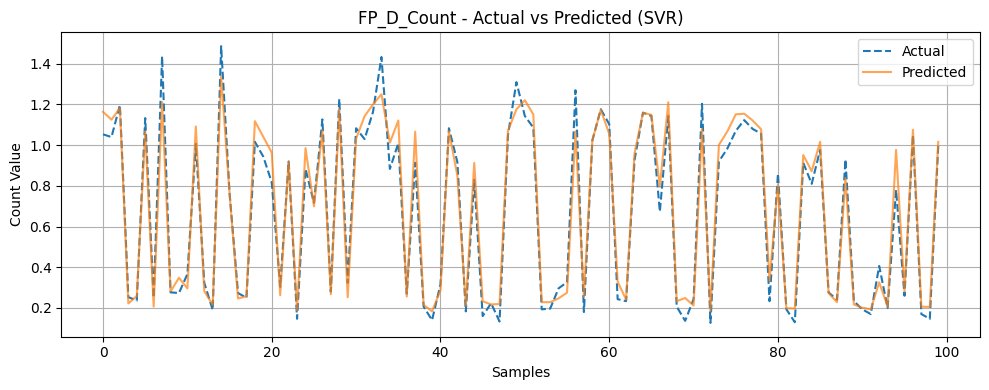

In [ ]:
#lag = 5 and print X_test, test size set to 0.2


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity

# ---------------- LOAD DATA ----------------
file_path = "junction_data_race_course.csv"
df = pd.read_csv(file_path)

# ---------------- STEP 1: DOWNSAMPLE TO 5 MINUTES ----------------
df_downsampled = df.groupby(np.arange(len(df)) // 300).mean(numeric_only=True).reset_index(drop=True)

# ---------------- STEP 2: CREATE LAG FEATURES + COSINE ----------------
def create_lagged_features_with_cosine(data, target_col="FP_D_Count", lag=5):
    if target_col not in data.columns:
        raise ValueError(f"{target_col} not found in dataset.")

    relevant_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    lagged = data[relevant_cols].copy()

    for l in range(1, lag + 1):
        for col in relevant_cols:
            lagged[f"{col}_lag{l}"] = data[col].shift(l)

    lagged = lagged.dropna().reset_index(drop=True)

    lag_cols = [col for col in lagged.columns if '_lag' in col]
    lagged_features = lagged[lag_cols]
    cos_sim_matrix = cosine_similarity(lagged_features)
    lagged['cosine_similarity'] = np.diag(cos_sim_matrix)

    feature_cols = [col for col in lagged.columns if col != target_col]
    X = lagged[feature_cols]
    y = lagged[target_col]
    return X, y

# ---------------- STEP 3: SVM REGRESSION ----------------
def run_svm_with_advanced_features(data, lag=5, target_col="FP_D_Count"):
    X, y = create_lagged_features_with_cosine(data, target_col=target_col, lag=lag)

    # Standardize features (important for SVM)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    # Train SVR model
    model = SVR(kernel='rbf', C=100, epsilon=0.1)
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n📊 Model Evaluation for FP_D_Count using SVR (5-min resolution, lag=5):")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")

    # Print X_test values
    print("\n🧪 Features in X_test (first 5 rows):")
    print(pd.DataFrame(X_test, columns=X.columns).head())

    # Plot actual vs predicted
    plt.figure(figsize=(10, 4))
    plt.plot(np.array(y_test[:100]), label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title(f"{target_col} - Actual vs Predicted (SVR)")
    plt.xlabel("Samples")
    plt.ylabel("Count Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ---------------- RUN FINAL SVM CODE ----------------
lag_value = 5
run_svm_with_advanced_features(df_downsampled, lag=lag_value)


<ipython-input-8-b41abea66217>:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lagged[f"{col}_lag{l}"] = data[col].shift(l)
<ipython-input-8-b41abea66217>:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lagged[f"{col}_lag{l}"] = data[col].shift(l)
<ipython-input-8-b41abea66217>:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, 


📊 Model Evaluation for FP_D_Count using SVR (5-min resolution, lag=5):
Mean Absolute Error (MAE): 0.06
Root Mean Squared Error (RMSE): 0.08
R² Score: 0.97

🧪 Features in X_test (first 5 rows):
       Time  FP_A_Count  FP_A_QueuePct  FP_A_Speed  FP_B_Count  FP_B_QueuePct  \
0 -0.853073    1.579128       1.157651    0.855123    0.301528       0.352240   
1  1.201290    2.058576       1.743238    0.768103    0.475170       0.525109   
2 -0.178326    0.989039       0.534048    1.373247    0.874547       0.987840   
3  0.365086   -1.160572      -1.227168   -1.080801   -1.070247      -1.120642   
4 -0.602452   -1.023587      -0.887772   -1.068179   -1.052882      -1.049049   

   FP_B_Speed  FP_C_Count  FP_C_QueuePct  FP_C_Speed  ...  \
0    0.414416    0.709713       0.788653    1.187885  ...   
1    1.240332    1.394497       1.440901    1.395850  ...   
2    0.853028    0.761394       0.690248    0.836194  ...   
3   -1.167041   -1.086230      -1.015439   -1.106907  ...   
4   -1.095468 

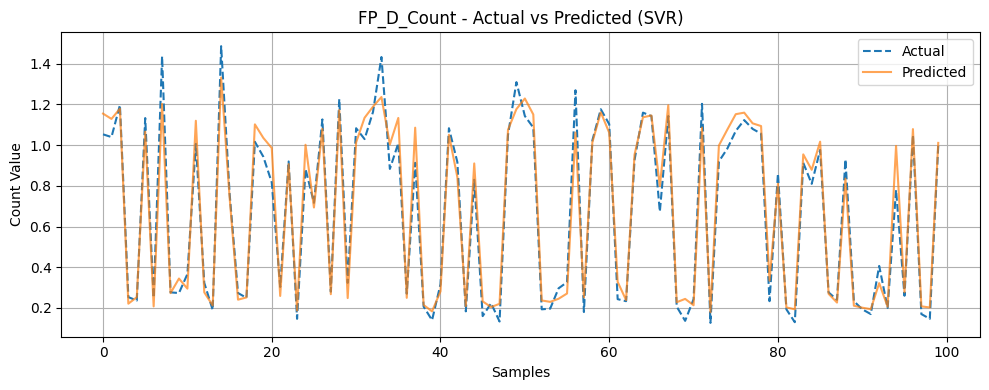

In [ ]:
#lag = 5 and print X_test, test size set to 0.3


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity

# ---------------- LOAD DATA ----------------
file_path = "junction_data_race_course.csv"
df = pd.read_csv(file_path)

# ---------------- STEP 1: DOWNSAMPLE TO 5 MINUTES ----------------
df_downsampled = df.groupby(np.arange(len(df)) // 300).mean(numeric_only=True).reset_index(drop=True)

# ---------------- STEP 2: CREATE LAG FEATURES + COSINE ----------------
def create_lagged_features_with_cosine(data, target_col="FP_D_Count", lag=5):
    if target_col not in data.columns:
        raise ValueError(f"{target_col} not found in dataset.")

    relevant_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    lagged = data[relevant_cols].copy()

    for l in range(1, lag + 1):
        for col in relevant_cols:
            lagged[f"{col}_lag{l}"] = data[col].shift(l)

    lagged = lagged.dropna().reset_index(drop=True)

    lag_cols = [col for col in lagged.columns if '_lag' in col]
    lagged_features = lagged[lag_cols]
    cos_sim_matrix = cosine_similarity(lagged_features)
    lagged['cosine_similarity'] = np.diag(cos_sim_matrix)

    feature_cols = [col for col in lagged.columns if col != target_col]
    X = lagged[feature_cols]
    y = lagged[target_col]
    return X, y

# ---------------- STEP 3: SVM REGRESSION ----------------
def run_svm_with_advanced_features(data, lag=5, target_col="FP_D_Count"):
    X, y = create_lagged_features_with_cosine(data, target_col=target_col, lag=lag)

    # Standardize features (important for SVM)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

    # Train SVR model
    model = SVR(kernel='rbf', C=100, epsilon=0.1)
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n📊 Model Evaluation for FP_D_Count using SVR (5-min resolution, lag=5):")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")

    # Print X_test values
    print("\n🧪 Features in X_test (first 5 rows):")
    print(pd.DataFrame(X_test, columns=X.columns).head())

    # Plot actual vs predicted
    plt.figure(figsize=(10, 4))
    plt.plot(np.array(y_test[:100]), label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title(f"{target_col} - Actual vs Predicted (SVR)")
    plt.xlabel("Samples")
    plt.ylabel("Count Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ---------------- RUN FINAL SVM CODE ----------------
lag_value = 5
run_svm_with_advanced_features(df_downsampled, lag=lag_value)


<ipython-input-1-58a94a17e5b8>:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lagged[f"{col}_lag{l}"] = data[col].shift(l)
<ipython-input-1-58a94a17e5b8>:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lagged[f"{col}_lag{l}"] = data[col].shift(l)
<ipython-input-1-58a94a17e5b8>:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, 


📊 10-Min Interval Model Evaluation:
MAE: 0.06, RMSE: 0.08, R²: 0.96

🧪 X_test sample:
       Time  FP_A_Count  FP_A_QueuePct  FP_A_Speed  FP_B_Count  FP_B_QueuePct  \
0  0.084490   -0.688971      -0.761325   -0.558963   -0.863820      -0.911817   
1  0.337961   -1.101366      -1.014556   -1.074795   -0.882727      -0.870177   
2 -0.212433    1.402848       1.724025    1.076187    1.906036       1.987364   
3  1.675322   -0.710676      -0.752197   -0.595317   -0.599124      -0.613239   
4  0.620400   -1.060669      -1.099335   -1.017757   -0.873273      -0.885319   

   FP_B_Speed  FP_C_Count  FP_C_QueuePct  FP_C_Speed  ...  \
0   -0.871726   -0.720266      -0.544292   -0.737575  ...   
1   -0.862972   -1.007417      -0.929218   -1.073009  ...   
2    1.756149    1.392349       2.754735    1.510933  ...   
3   -0.491055   -0.563016      -0.496049   -0.684420  ...   
4   -0.966159   -1.096298      -1.001412   -1.272569  ...   

   Anand_Rao_Jnc_Count_lag5  Anand_Rao_Jnc_QueuePct_lag5  \

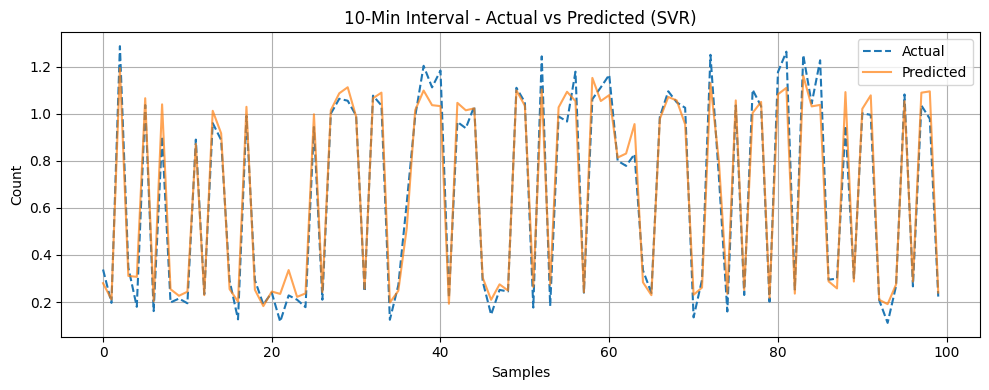

In [ ]:
#10 minute interval


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity

# Load data
df = pd.read_csv("junction_data_race_course.csv")

# Downsample to 10-minute intervals (600 seconds)
df_downsampled = df.groupby(np.arange(len(df)) // 600).mean(numeric_only=True).reset_index(drop=True)

# Create lag features with cosine similarity
def create_lagged_features_with_cosine(data, target_col="FP_D_Count", lag=5):
    relevant_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    lagged = data[relevant_cols].copy()

    for l in range(1, lag + 1):
        for col in relevant_cols:
            lagged[f"{col}_lag{l}"] = data[col].shift(l)

    lagged = lagged.dropna().reset_index(drop=True)

    lag_cols = [col for col in lagged.columns if '_lag' in col]
    lagged_features = lagged[lag_cols]
    cos_sim_matrix = cosine_similarity(lagged_features)
    lagged['cosine_similarity'] = np.diag(cos_sim_matrix)

    feature_cols = [col for col in lagged.columns if col != target_col]
    X = lagged[feature_cols]
    y = lagged[target_col]
    return X, y

# Run SVR
def run_svm_with_advanced_features(data, lag=5, target_col="FP_D_Count"):
    X, y = create_lagged_features_with_cosine(data, target_col=target_col, lag=lag)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
    model = SVR(kernel='rbf', C=100, epsilon=0.1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n📊 10-Min Interval Model Evaluation:")
    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}")
    print("\n🧪 X_test sample:")
    print(pd.DataFrame(X_test, columns=X.columns).head())

    plt.figure(figsize=(10, 4))
    plt.plot(np.array(y_test[:100]), label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title("10-Min Interval - Actual vs Predicted (SVR)")
    plt.xlabel("Samples")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Run the model
run_svm_with_advanced_features(df_downsampled, lag=5)


<ipython-input-2-203d12c3da01>:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lagged[f"{col}_lag{l}"] = data[col].shift(l)
<ipython-input-2-203d12c3da01>:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lagged[f"{col}_lag{l}"] = data[col].shift(l)
<ipython-input-2-203d12c3da01>:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, 


📊 30-Min Interval Model Evaluation:
MAE: 0.07, RMSE: 0.08, R²: 0.96

🧪 X_test sample:
       Time  FP_A_Count  FP_A_QueuePct  FP_A_Speed  FP_B_Count  FP_B_QueuePct  \
0  1.006415   -0.917702      -0.863668   -0.828818   -0.901958      -0.885592   
1  1.349179   -0.880827      -0.769845   -0.914204   -1.098860      -1.109385   
2 -1.662772    0.141530       0.121992    0.369966    0.249422       0.244554   
3 -1.196029    1.120559       1.197935    1.042882    0.469685       0.354031   
4  0.853265    1.007168       1.301082    1.080104    0.980297       0.974343   

   FP_B_Speed  FP_C_Count  FP_C_QueuePct  FP_C_Speed  ...  \
0   -0.778385   -0.904983      -0.844323   -0.867761  ...   
1   -1.097461   -1.095507      -1.058031   -1.084117  ...   
2    0.316744    0.173858       0.195438    0.191363  ...   
3    0.525402    0.754956       0.596869    1.046079  ...   
4    1.068251    1.707575       1.594740    1.161568  ...   

   Anand_Rao_Jnc_Count_lag5  Anand_Rao_Jnc_QueuePct_lag5  \

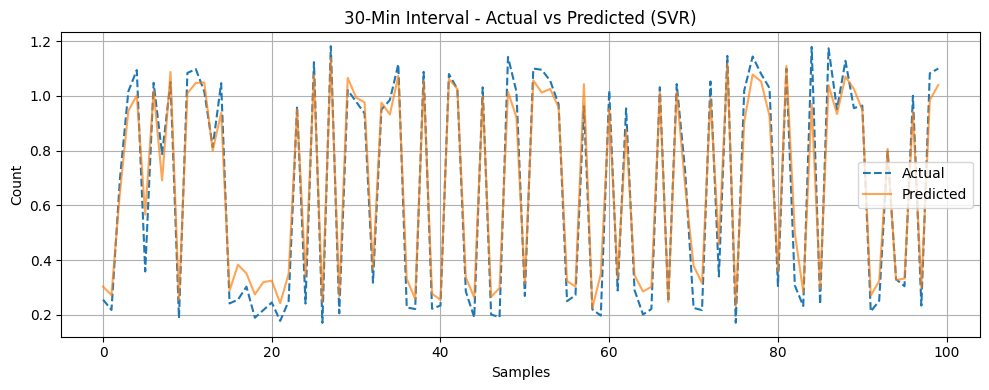

In [ ]:
#30-minute interval


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity

# Load data
df = pd.read_csv("junction_data_race_course.csv")

# Downsample to 30-minute intervals (1800 seconds)
df_downsampled = df.groupby(np.arange(len(df)) // 1800).mean(numeric_only=True).reset_index(drop=True)

# Create lag features with cosine similarity
def create_lagged_features_with_cosine(data, target_col="FP_D_Count", lag=5):
    relevant_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    lagged = data[relevant_cols].copy()

    for l in range(1, lag + 1):
        for col in relevant_cols:
            lagged[f"{col}_lag{l}"] = data[col].shift(l)

    lagged = lagged.dropna().reset_index(drop=True)

    lag_cols = [col for col in lagged.columns if '_lag' in col]
    lagged_features = lagged[lag_cols]
    cos_sim_matrix = cosine_similarity(lagged_features)
    lagged['cosine_similarity'] = np.diag(cos_sim_matrix)

    feature_cols = [col for col in lagged.columns if col != target_col]
    X = lagged[feature_cols]
    y = lagged[target_col]
    return X, y

# Run SVR
def run_svm_with_advanced_features(data, lag=5, target_col="FP_D_Count"):
    X, y = create_lagged_features_with_cosine(data, target_col=target_col, lag=lag)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
    model = SVR(kernel='rbf', C=100, epsilon=0.1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n📊 30-Min Interval Model Evaluation:")
    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}")
    print("\n🧪 X_test sample:")
    print(pd.DataFrame(X_test, columns=X.columns).head())

    plt.figure(figsize=(10, 4))
    plt.plot(np.array(y_test[:100]), label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title("30-Min Interval - Actual vs Predicted (SVR)")
    plt.xlabel("Samples")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Run the model
run_svm_with_advanced_features(df_downsampled, lag=5)


<ipython-input-3-894fd2709d67>:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lagged[f"{col}_lag{l}"] = data[col].shift(l)
<ipython-input-3-894fd2709d67>:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lagged[f"{col}_lag{l}"] = data[col].shift(l)
<ipython-input-3-894fd2709d67>:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, 


📊 45-Min Interval Model Evaluation:
MAE: 0.07, RMSE: 0.09, R²: 0.95

🧪 X_test sample:
       Time  FP_A_Count  FP_A_QueuePct  FP_A_Speed  FP_B_Count  FP_B_QueuePct  \
0  0.538863    2.042156       1.841167    0.972838    0.890359       0.937577   
1 -1.363653   -1.052243      -0.975313   -1.141065   -1.293717      -1.314958   
2  0.065983   -0.858999      -0.850660   -0.722233   -0.932732      -0.956920   
3 -0.868779    1.007771       0.754575    1.120079    0.972092       0.943258   
4 -0.703821   -1.112905      -1.226378   -1.235236   -1.089386      -1.062025   

   FP_B_Speed  FP_C_Count  FP_C_QueuePct  FP_C_Speed  ...  \
0    1.013096    1.374192       1.321735    0.963134  ...   
1   -1.346261   -1.220269      -1.146785   -1.345688  ...   
2   -0.920838   -0.875742      -0.799305   -0.858148  ...   
3    1.043946    1.162301       1.275118    1.146065  ...   
4   -1.099068   -1.008377      -0.958673   -1.003827  ...   

   Anand_Rao_Jnc_Count_lag5  Anand_Rao_Jnc_QueuePct_lag5  \

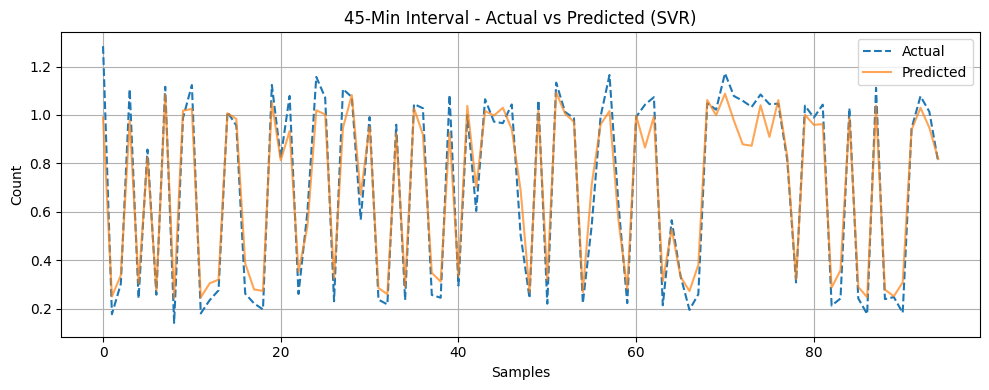

In [ ]:
#45-minute interval


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity

# Load data
df = pd.read_csv("junction_data_race_course.csv")

# Downsample to 45-minute intervals (2700 seconds)
df_downsampled = df.groupby(np.arange(len(df)) // 2700).mean(numeric_only=True).reset_index(drop=True)

# Create lag features with cosine similarity
def create_lagged_features_with_cosine(data, target_col="FP_D_Count", lag=5):
    relevant_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    lagged = data[relevant_cols].copy()

    for l in range(1, lag + 1):
        for col in relevant_cols:
            lagged[f"{col}_lag{l}"] = data[col].shift(l)

    lagged = lagged.dropna().reset_index(drop=True)

    lag_cols = [col for col in lagged.columns if '_lag' in col]
    lagged_features = lagged[lag_cols]
    cos_sim_matrix = cosine_similarity(lagged_features)
    lagged['cosine_similarity'] = np.diag(cos_sim_matrix)

    feature_cols = [col for col in lagged.columns if col != target_col]
    X = lagged[feature_cols]
    y = lagged[target_col]
    return X, y

# Run SVR
def run_svm_with_advanced_features(data, lag=5, target_col="FP_D_Count"):
    X, y = create_lagged_features_with_cosine(data, target_col=target_col, lag=lag)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
    model = SVR(kernel='rbf', C=100, epsilon=0.1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n📊 45-Min Interval Model Evaluation:")
    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}")
    print("\n🧪 X_test sample:")
    print(pd.DataFrame(X_test, columns=X.columns).head())

    plt.figure(figsize=(10, 4))
    plt.plot(np.array(y_test[:100]), label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title("45-Min Interval - Actual vs Predicted (SVR)")
    plt.xlabel("Samples")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Run the model
run_svm_with_advanced_features(df_downsampled, lag=5)
